# Plots for the JAXAtari paper
Needed:
1. Reward curve comparisons (y-axis: environment return ALE vs JAXAtari)
    - two x-axis versions: total_env_frames and wallclock-time
    - on a number of games (e.g. Pong/Seaquest/..)
2. Throughput comparison (x-axis: number of parallel envs, y-axis: steps/second, gymnasium ALE vs envpool ALE vs JAXAtari)

## 1. Throughput comparison

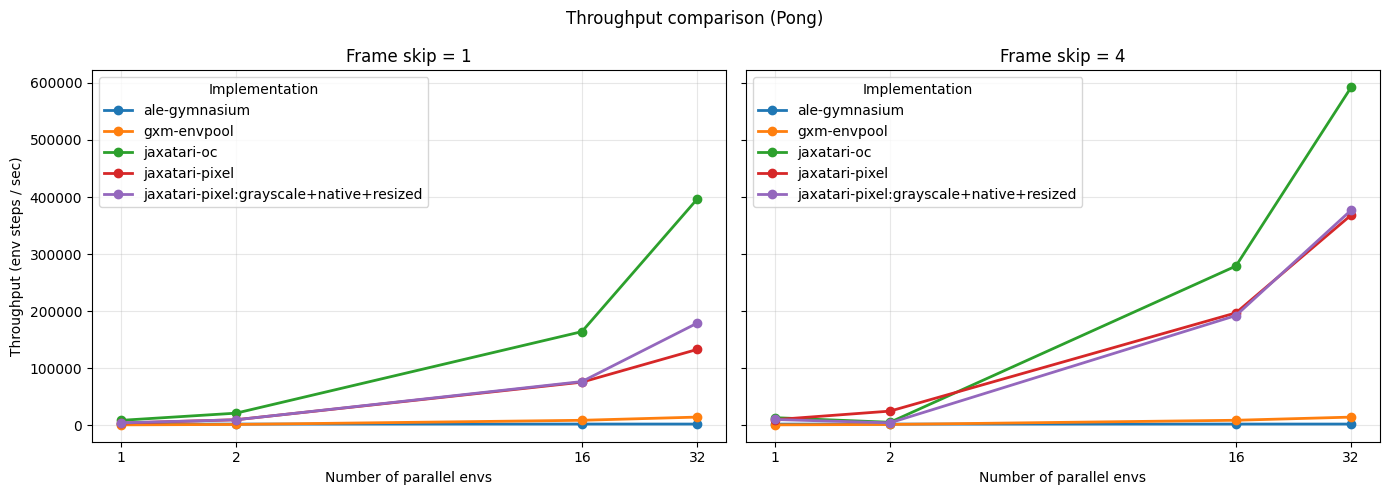

{1: method_base  ale-gymnasium   gxm-envpool    jaxatari-oc  jaxatari-pixel  \
 num_envs                                                                  
 1              1979.476162    703.674294    8545.078739     3799.144043   
 2              2020.487023   1376.366367   21179.212165     9632.941572   
 16             2094.180559   8677.626024  164061.444602    75511.720422   
 32             2072.295445  14289.854706  396439.836641   132886.258431   
 
 method_base  jaxatari-pixel:grayscale+native+resized  
 num_envs                                              
 1                                        4179.007189  
 2                                        9556.830786  
 16                                      76582.900861  
 32                                     179001.839063  ,
 4: method_base  ale-gymnasium   gxm-envpool    jaxatari-oc  jaxatari-pixel  \
 num_envs                                                                  
 1              1975.495452    713.954378   132

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_path = Path("./outputs/2026-02-25/throughput_all_fs1_fs4.csv")

df = pd.read_csv(csv_path)

# Build readable labels for each implementation variant.
df["method_base"] = df["backend"]

is_ale = df["backend"].eq("ale")
is_gxm = df["backend"].eq("gxm")
is_jaxatari = df["backend"].eq("jaxatari")

df.loc[is_ale, "method_base"] = "ale-gymnasium"

# gxm rows in this benchmark correspond to the envpool backend.
df.loc[is_gxm, "method_base"] = "gxm-envpool"

if "jaxatari_mode" in df.columns:
    mode = df["jaxatari_mode"].fillna("")
    method_jax = "jaxatari-" + mode.replace({"": "unknown"})

    # Keep special pixel options visible (e.g., grayscale+native+resized).
    if "pixel_options" in df.columns:
        pixel_opts = df["pixel_options"].fillna("").str.strip()
        has_opts = is_jaxatari & pixel_opts.ne("")
        method_jax = method_jax.where(~has_opts, method_jax + ":" + pixel_opts)

    df.loc[is_jaxatari, "method_base"] = method_jax[is_jaxatari]

fs_values = sorted(df["atari_frame_skip"].dropna().astype(int).unique())
if len(fs_values) != 2:
    raise ValueError(f"Expected exactly two frame skip values, got: {fs_values}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

pivot_tables = {}

for ax, frame_skip in zip(axes, fs_values):
    fs_df = df[df["atari_frame_skip"].astype(int).eq(frame_skip)].copy()
    plot_df = (
        fs_df.groupby(["num_envs", "method_base"], as_index=False)["throughput_env_steps_per_sec"]
        .max()
        .sort_values(["method_base", "num_envs"])
)

    for method, group in plot_df.groupby("method_base"):
        ax.plot(
            group["num_envs"],
            group["throughput_env_steps_per_sec"],
            marker="o",
            linewidth=2,
            label=method,
        )

    ax.set_xscale("log", base=2)
    ax.set_xticks(sorted(plot_df["num_envs"].unique()))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.set_xlabel("Number of parallel envs")
    ax.set_title(f"Frame skip = {frame_skip}")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Implementation", loc="upper left")

    pivot_tables[frame_skip] = plot_df.pivot(
        index="num_envs",
        columns="method_base",
        values="throughput_env_steps_per_sec",
    )

axes[0].set_ylabel("Throughput (env steps / sec)")
fig.suptitle("Throughput comparison (Pong)")

plt.tight_layout()
plt.show()

pivot_tables

In [4]:
# Speedup of JAXAtari variants over ALE and EnvPool (GXM)
comparison_df = df.copy()

# Throughput per backend/method/frame-skip/env-count
agg = (
    comparison_df.groupby(["atari_frame_skip", "num_envs", "method_base"], as_index=False)["throughput_env_steps_per_sec"]
    .max()
    .sort_values(["atari_frame_skip", "num_envs", "method_base"])
)

# Baselines (same frame skip + num_envs)
ale_base = (
    agg[agg["method_base"].eq("ale-gymnasium")][["atari_frame_skip", "num_envs", "throughput_env_steps_per_sec"]]
    .rename(columns={"throughput_env_steps_per_sec": "ale_throughput"})
)

gxm_base = (
    agg[agg["method_base"].eq("gxm-envpool")][["atari_frame_skip", "num_envs", "throughput_env_steps_per_sec"]]
    .rename(columns={"throughput_env_steps_per_sec": "gxm_throughput"})
)

jax_only = agg[agg["method_base"].str.startswith("jaxatari-")].copy()

speedup_df = (
    jax_only.merge(ale_base, on=["atari_frame_skip", "num_envs"], how="left")
    .merge(gxm_base, on=["atari_frame_skip", "num_envs"], how="left")
)

speedup_df["speedup_vs_ale"] = speedup_df["throughput_env_steps_per_sec"] / speedup_df["ale_throughput"]
speedup_df["speedup_vs_gxm"] = speedup_df["throughput_env_steps_per_sec"] / speedup_df["gxm_throughput"]

speedup_table = speedup_df[[
    "atari_frame_skip",
    "num_envs",
    "method_base",
    "throughput_env_steps_per_sec",
    "ale_throughput",
    "gxm_throughput",
    "speedup_vs_ale",
    "speedup_vs_gxm",
]].sort_values(["atari_frame_skip", "num_envs", "method_base"])

# Compact view with rounded speedups
speedup_table_rounded = speedup_table.copy()
speedup_table_rounded["speedup_vs_ale"] = speedup_table_rounded["speedup_vs_ale"].round(2)
speedup_table_rounded["speedup_vs_gxm"] = speedup_table_rounded["speedup_vs_gxm"].round(2)

speedup_table_rounded

,atari_frame_skip,num_envs,method_base,throughput_env_steps_per_sec,ale_throughput,gxm_throughput,speedup_vs_ale,speedup_vs_gxm
0,1,1,jaxatari-oc,8545.078739,1979.476162,703.674294,4.32,12.14
1,1,1,jaxatari-pixel,3799.144043,1979.476162,703.674294,1.92,5.40
2,1,1,jaxatari-pixel:grayscale+native+resized,4179.007189,1979.476162,703.674294,2.11,5.94
3,1,2,jaxatari-oc,21179.212165,2020.487023,1376.366367,10.48,15.39
4,1,2,jaxatari-pixel,9632.941572,2020.487023,1376.366367,4.77,7.00
5,1,2,jaxatari-pixel:grayscale+native+resized,9556.830786,2020.487023,1376.366367,4.73,6.94
6,1,16,jaxatari-oc,164061.444602,2094.180559,8677.626024,78.34,18.91
7,1,16,jaxatari-pixel,75511.720422,2094.180559,8677.626024,36.06,8.70
8,1,16,jaxatari-pixel:grayscale+native+resized,76582.900861,2094.180559,8677.626024,36.57,8.83
9,1,32,jaxatari-oc,396439.836641,2072.295445,14289.854706,191.30,27.74
